In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
hbar = 1
#hbar = 6.62607015*10**(-34)

In [3]:
#Function that creates a two-mode squeezed thermal state
def init_sq_th(alpha_: np.float64, theta_: np.float64, mean_n_: np.float64):
    #Initialize the thermal vacuum state
    th_vac_matrix_ = np.zeros((4,4), dtype=np.float64)
    np.fill_diagonal(th_vac_matrix_, mean_n_ + 1/2)

    #Initialize the two-mode squeezing matrix
    sq_matrix_ = np.zeros((4,4), dtype=np.float64)
    np.fill_diagonal(sq_matrix_, np.cosh(alpha_))
    sq_matrix_[0][2], sq_matrix_[2][0] = np.sinh(alpha_)*np.cos(theta_), np.sinh(alpha_)*np.cos(theta_)
    sq_matrix_[0][3], sq_matrix_[3][0] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix_[1][2], sq_matrix_[2][1] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix_[1][3], sq_matrix_[3][1] = -np.sinh(alpha_)*np.cos(theta_), -np.sinh(alpha_)*np.cos(theta_)

    #Return the squeezed thermal state and get rid of floating point erros
    result_ = sq_matrix_ @ th_vac_matrix_ @ sq_matrix_.T
    result_[0][1], result_[1][0], result_[2][3], result_[3][2] = 0, 0, 0, 0
    return result_

#Creates two-mode input states in bulk
def create_bipartite_states(type_: str, amount_of_states_: np.float64):
    #Squeezed thermal states
    if type_ == "sq_th":
        theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states_,))
        s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states_,))
        phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states_,))
        abs_alpha_sq_th_ = np.array([x*np.sin(y) for x, y in zip(s_sq_th_,phi_sq_th_)])
        mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

        #return covariance matrices for input states
        return np.array([init_sq_th(x,y,z) for x,y,z in zip(abs_alpha_sq_th_,theta_sq_th_,mean_n_sq_th_)])
    else:
        print(f"{type_} not possible")

#Changes the input state interacting with the reservoir
def inject_input(cov_M_: np.array, input_state_: np.array):
    cov_M_[:4,4:] = 0
    cov_M_[4:,:4] = 0
    cov_M_[:4,:4] = input_state_

#Initializes the covariance matrix
def init_cov_full():
    cov_full_ = np.zeros((12,12), dtype=np.float64)
    np.fill_diagonal(cov_full_[4:,4:], 1/2)
    return cov_full_

#Initializes the matrix A (drift matrix) which contains the deterministic information of the Langevin equations
def init_A(gamma_: np.float64, P_: np.float64, W_in_: np.array, J_ij_: np.array, eta_: np.float64):
    A_ = np.zeros((12,12), dtype=np.float64)
    #First 1-4x1-4 submatrix
    A_[0][0], A_[1][1], A_[2][2], A_[3][3] =  -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_)
    #5-12x1-4 submatrix
    A_[4][0], A_[6][0], A_[8][0], A_[10][0] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[5][1], A_[7][1], A_[9][1], A_[11][1] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[4][2], A_[6][2],A_[8][2], A_[10][2] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[5][3], A_[7][3], A_[9][3], A_[11][3] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    #5-12x5-12 submatrix diagonal
    A_[4][4], A_[6][6], A_[8][8], A_[10][10] = -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2
    A_[5][5], A_[7][7], A_[9][9], A_[11][11] = -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2
    #5-12x5-12 submatrix other values row by row
    A_[4][7], A_[4][9], A_[4][11], A_[5][6], A_[5][8], A_[5][10] = J_ij_[0], J_ij_[1], J_ij_[2], -J_ij_[0], -J_ij_[1], -J_ij_[2]
    A_[6][5], A_[6][9], A_[6][11], A_[7][4], A_[7][8], A_[7][10] = J_ij_[0], J_ij_[3], J_ij_[4], -J_ij_[0], -J_ij_[3], -J_ij_[4]
    A_[8][5], A_[8][7], A_[8][11], A_[9][4], A_[9][6], A_[9][10] = J_ij_[1], J_ij_[3], J_ij_[5], -J_ij_[1], -J_ij_[3], -J_ij_[5]
    A_[10][5],  A_[10][7], A_[10][9], A_[11][4], A_[11][6], A_[11][8] = J_ij_[2], J_ij_[4], J_ij_[5], -J_ij_[2], -J_ij_[4], -J_ij_[5]

    A_ = (1/hbar)*A_
    
    #Initialize first mode interaction matrix
    first_mode_ = copy.copy(A_)
    first_mode_[:,[2,3]] = 0
    #Initialize second mode interaction matrix
    second_mode_ = copy.copy(A_)
    second_mode_[:,[0,1]] = 0
    #Initialize A mode with only reservoir interaction (at times 0, tau, 2*tau)
    nointeract_mode_ = copy.copy(A_)
    nointeract_mode_[:,[0,1,2,3]] = 0

    #Return the different interaction modes
    return (first_mode_, second_mode_, nointeract_mode_, A_)

#Initializes the matrix D (diffusion matrix) which contains the stochastic noise of the Langevin equations
def init_D(gamma_: np.float64, P_: np.float64, eta_: np.float64):
    D_ = np.zeros((12,12), dtype=np.float64)
    np.fill_diagonal(D_[:4,:4], eta_/(2*gamma_))
    np.fill_diagonal(D_[4:,4:], (gamma_-P_)/2)

    first_mode_ = copy.copy(D_)
    first_mode_[:,[2,3]] = 0
    #Initialize second mode interaction matrix
    second_mode_ = copy.copy(D_)
    second_mode_[:,[0,1]] = 0
    #Initialize A mode with only reservoir interaction
    nointeract_mode_ = copy.copy(D_)
    nointeract_mode_[:,[0,1,2,3]] = 0

    return (first_mode_, second_mode_, nointeract_mode_, D_)

#Evolves system for one input
def time_evolve(cov_M_: np.array, first_mode_A_: np.array, second_mode_A_:np.array, nointeract_mode_A_: np.array,
                first_mode_D_: np.array, second_mode_D_:np.array, nointeract_mode_D_: np.array, time_steps_: np.float64, tau_: np.float64):

    #Piecewice function that determines returns the correct interaction between input and reservoir
    def piecewice(t_, _cov_M_):
        t_ = np.round(t_, 6)
        if 0 < t_ < tau_:
            return first_mode_A_ @ _cov_M_ + _cov_M_ @ first_mode_A_.T + first_mode_D_
        elif tau_ < t_ < 2*tau_:
            return second_mode_A_ @ _cov_M_ + _cov_M_ @ second_mode_A_.T + second_mode_D_
        else:
            return nointeract_mode_A_ @ _cov_M_ + _cov_M_ @ nointeract_mode_A_.T + nointeract_mode_D_
    
    #Getting rid op floating point error in step size
    step_size_ = np.round(2*tau_/time_steps_,6)

    #Regular 4-step Runge-Kutta numerical integration function
    def rk4(function_, t_, _cov_M_, step_):
        k1_ = function_(t_, _cov_M_)
        k2_ = function_(t_ + 0.5 * step_, _cov_M_ + 0.5 * step_ * k1_)
        k3_ = function_(t_ + 0.5 * step_, _cov_M_ + 0.5 * step_ * k2_)
        k4_ = function_(t_ + step_, _cov_M_ + step_ * k3_)
        return cov_M_ + (step_/6)*(k1_ + 2 * k2_ + 2 * k3_ + k4_)

    #Evolve the covariance matrix
    for current_time in np.arange(0, 2*tau_, step_size_):
        cov_M_ = rk4(piecewice, current_time, cov_M_, step_size_)
        
    #Return the time-evolved covariance matrix
    return cov_M_

#Calculates the occupation numbers of reservoir sites
def get_occupation_nums(cov_M_: np.array, reservoir_size_: np.float64):
    return np.array([(1/2)*(cov_M_[4+2*i][4+2*i] + cov_M_[5+2*i][5+2*i] - 1) for i in range(reservoir_size_)])

#Predicts probabilities for the input to be entangled and separable
def predict_Y_out(occupation_numbers_: np.array, W_out_: np.array):
    return occupation_numbers_ @ W_out_

#Predicts entanglement of input
def predict_Y_out_entanglement(occupation_numbers_: np.array, W_out_: np.array):
    pred_ = occupation_numbers_ @ W_out_

    if pred_[0] > pred_[1]:
        return (1,0)
    return (0,1)

#Updates the output weights of network (W_{t+1} = W_t - learn_rate*(XX^T+reg_str*I)*W_t - Xy^T)
def update_W_out(learning_rate_: np.float64, reg_strength_: np.float64, Y_true_: tuple, occupation_numbers_: np.array, W_out_: np.array, reservoir_size_: np.float64):
    gradient_ = (np.outer(occupation_numbers_, occupation_numbers_) + reg_strength_*np.eye(reservoir_size_)) @ W_out_ - np.outer(occupation_numbers_, Y_true_)
    return W_out_ - learning_rate_*gradient_

#Calculates negativity of input state
def negativity(input_state_: np.array):
    det_V_ = np.linalg.det(input_state_)
    det_A_ = np.linalg.det(input_state_[:2,:2])  
    det_B_ = np.linalg.det(input_state_[2:,2:])
    det_C_ = np.linalg.det(input_state_[:2,2:])
    sigma_ = det_A_ + det_B_ - 2*det_C_
    return -np.log(np.sqrt(2)*(np.sqrt(sigma_ - np.sqrt(sigma_**2 - 4*det_V_))))

#Reveals true entanglement of input
def assign_entanglement(negativity_: np.float64):
    if negativity_ > 0:
        return (1,0)
    return (0,1)
    
#Returns true entanglement values in bulk of input states
def get_entanglement_values(input_states_):
    return np.array([assign_entanglement(negativity(input_)) for input_ in input_states_])


In [4]:
#Initialize variables
reservoir_size = 4

number_of_train_inputs = 200
number_of_sq_th_inputs = 200

#Create input states
input_states_train = create_bipartite_states("sq_th", number_of_train_inputs)
input_states_test_sq_th = create_bipartite_states("sq_th", number_of_sq_th_inputs)

#Get true entanglement of input states
Y_out_true_train = get_entanglement_values(input_states_train)
Y_out_true_test_sq_th = get_entanglement_values(input_states_test_sq_th)

#Initialize empty lists for occupation numbers
occupation_nums_train = []
occupation_nums_sq_th = []

#Initialize empty arrays for predicted entanglement
Y_out_pred_train = np.empty(number_of_train_inputs, dtype=tuple)
Y_out_pred_sq_th = np.empty(number_of_sq_th_inputs, dtype=tuple)

#Initialize empty array for prediction probability of entanglement and separability
actual = np.empty(number_of_train_inputs, dtype=tuple)

#Initialize variables
gamma = 0.1
P = 0.1*gamma
tau = hbar/gamma

W_in = np.random.uniform(0, gamma, (4,))
J_ij = np.random.uniform(-gamma, gamma, (6,))
eta = np.sum(W_in**2)

learning_rate = 0.1
regularization_strength = 0.05

In [11]:
input_states_train[3]

array([[ 1.35367164,  0.        , -0.33558656, -0.6726542 ],
       [ 0.        ,  1.35367164, -0.6726542 ,  0.33558656],
       [-0.33558656, -0.6726542 ,  1.35367164,  0.        ],
       [-0.6726542 ,  0.33558656,  0.        ,  1.35367164]])

In [6]:
#Initialize covariance matrix and matrices A and D
cov_full = init_cov_full()
first_mode_A, second_mode_A, nointeract_mode_A, matrix_A = init_A(gamma, P, W_in, J_ij, eta)
first_mode_D, second_mode_D, nointeract_mode_D, matrix_D = init_D(gamma, P, eta)

#Time steps for Runge-Kutta
time_steps = 8

#Simulate the quantum reservoir for the injection of initial training states
for idx, input in enumerate(input_states_train):
    inject_input(cov_full, input)
    cov_full = time_evolve(cov_full, first_mode_A, second_mode_A, nointeract_mode_A, first_mode_D, second_mode_D, nointeract_mode_D, time_steps, tau)
    occupation_nums_train.append(get_occupation_nums(cov_full, reservoir_size))
    #print("")
    #print(idx)
    #print(np.round(cov_full.diagonal()[4:], 3))

    #Print messages to see how differently classified states change the occupation numbers
    #if Y_out_true_train[idx][0] == 1:
    #    print("Entagled")
    #else:
    #    print("Separable")
    #print(occupation_nums_train[idx])
    
    #print(Y_out_true_train[idx])
    #print(np.round(cov_full,2))
    

In [7]:
#Initialize ranfom values for output weights of the system
#W_out = np.array([[0,0],[0,0],[0,0],[0,0]], dtype=np.float64)
W_out = np.random.uniform(0, 1, (4,2))
#print(W_out)
#Train the model to predict entanglement
for idx, occ_nums in enumerate(occupation_nums_train):
    Y_out_pred_train[idx] = predict_Y_out_entanglement(occ_nums, W_out)
    actual[idx] = predict_Y_out(occ_nums, W_out)
    W_out = update_W_out(learning_rate, regularization_strength, Y_out_true_train[idx], occ_nums, W_out, reservoir_size)
    #print("")
    #print(idx)
    #print(W_out)
    #print(occ_nums)
    #print(np.round(W_out, 3))
    

IndexError: index 200 is out of bounds for axis 0 with size 200

In [ ]:
#Print values during training to see the progress in training
correct = 0
for true, pred, actuals in zip(Y_out_true_train, Y_out_pred_train, actual):
    #print(f"True: {true}, Pred: ({np.round(pred[0],2)},{np.round(pred[1],2)}), Actual: ({actuals[0]},{actuals[1]})")
    if true[0] == pred[0]:
        correct += 1

print(f"\nDuring training the amount of correct guesses: {correct}")


True: [0 1], Pred: (0,1), Actual: (0.2282294828784424,0.3632723739105421)
True: [1 0], Pred: (0,1), Actual: (0.30577177040702364,0.5108221825500461)
True: [0 1], Pred: (0,1), Actual: (0.2948195866812121,0.4273914590510314)
True: [1 0], Pred: (0,1), Actual: (0.3119926288581651,0.4883367172887493)
True: [0 1], Pred: (0,1), Actual: (0.3135166620058346,0.4339992356784974)
True: [1 0], Pred: (0,1), Actual: (0.3446862279895395,0.5165277474855695)
True: [0 1], Pred: (0,1), Actual: (0.3281484269261482,0.4327251015426234)
True: [1 0], Pred: (0,1), Actual: (0.36289930328723835,0.5192914430778973)
True: [1 0], Pred: (0,1), Actual: (0.3685461808507443,0.4656901960723522)
True: [1 0], Pred: (0,1), Actual: (0.35565237683456663,0.4035041862124932)
True: [1 0], Pred: (0,1), Actual: (0.37427889315205276,0.38820719829998523)
True: [0 1], Pred: (1,0), Actual: (0.3744943919144811,0.3558973574120081)
True: [1 0], Pred: (0,1), Actual: (0.4283366720510233,0.4434534529906949)
True: [1 0], Pred: (1,0), Actual:

In [11]:
#Simulate the quantum reservoir for the injection of unseen squeezed thermal states
for idx, input in enumerate(input_states_test_sq_th):
    inject_input(cov_full, input)
    cov_full = time_evolve(cov_full, first_mode_A, second_mode_A, nointeract_mode_A, first_mode_D, second_mode_D, nointeract_mode_D, time_steps, tau)
    occupation_nums_sq_th.append(get_occupation_nums(cov_full, reservoir_size))

In [12]:
#Predict entanglement of squeezed thermal states
correct = 0

for idx, occ_nums in enumerate(occupation_nums_sq_th):
    Y_true = Y_out_true_test_sq_th[idx]
    Y_pred = Y_out_pred_sq_th[idx] = predict_Y_out_entanglement(occ_nums, W_out)
    actual = predict_Y_out(occ_nums, W_out)
    print(f"true {Y_true}, pred {Y_pred}, actual {actual}")
    if Y_true[0] == Y_pred[0]:
        correct += 1

print(f"\nThehe amount of correct guesses: {correct}")

true [1 0], pred (1, 0), actual [0.72712879 0.61923088]
true [0 1], pred (1, 0), actual [0.66060953 0.55632554]
true [1 0], pred (1, 0), actual [0.71680008 0.61119552]
true [0 1], pred (1, 0), actual [0.62617455 0.52584062]
true [1 0], pred (1, 0), actual [0.72942055 0.62391358]
true [0 1], pred (1, 0), actual [0.62999545 0.52813205]
true [1 0], pred (1, 0), actual [0.65307655 0.55541401]
true [1 0], pred (1, 0), actual [0.76726687 0.65505661]
true [1 0], pred (1, 0), actual [0.68026357 0.57221241]
true [1 0], pred (1, 0), actual [0.74152386 0.6331959 ]
true [1 0], pred (1, 0), actual [0.81013887 0.69029503]
true [0 1], pred (1, 0), actual [0.73036685 0.61668488]
true [1 0], pred (1, 0), actual [0.72559694 0.61712277]
true [1 0], pred (1, 0), actual [0.7756882  0.66083332]
true [1 0], pred (1, 0), actual [0.68567794 0.57772629]
true [1 0], pred (1, 0), actual [0.68729286 0.58419485]
true [0 1], pred (1, 0), actual [0.65169908 0.55046768]
true [0 1], pred (1, 0), actual [0.68227191 0.57

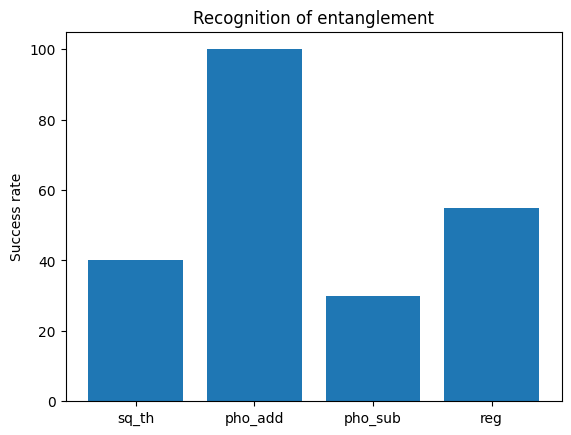

In [12]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [13]:
print(np.round(matrix_A,2))

[[-0.6   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.6   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.6   0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -0.6   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-0.77  0.   -0.77  0.   -0.45  0.    0.    0.47  0.    0.    0.   -0.54]
 [ 0.   -0.77  0.   -0.77  0.   -0.45 -0.47  0.   -0.    0.    0.54  0.  ]
 [-0.01  0.   -0.01  0.    0.    0.47 -0.45  0.    0.    0.62  0.    0.22]
 [ 0.   -0.01  0.   -0.01 -0.47  0.    0.   -0.45 -0.62  0.   -0.22  0.  ]
 [-0.4   0.   -0.4   0.    0.    0.    0.    0.62 -0.45  0.    0.   -0.  ]
 [ 0.   -0.4   0.   -0.4  -0.    0.   -0.62  0.    0.   -0.45  0.    0.  ]
 [-0.66  0.   -0.66  0.    0.   -0.54  0.    0.22  0.   -0.   -0.45  0.  ]
 [ 0.   -0.66  0.   -0.66  0.54  0.   -0.22  0.    0.    0.    0.   -0.45]]


In [14]:
#Check if the intervals for variables when creating a squeezed thermal state, according to the paper "Quantum reservoir computing",
#actually produce an equal amount of entangled and separable states
states = create_bipartite_states("sq_th", 100000)
ent_values = get_entanglement_values(states)

ent_counter = 0
for ent in ent_values:
    if ent[0] == 1:
        ent_counter += 1

#Random function for reference
random_vals = np.random.uniform(0,1,(100000,))
amount = 0
for value in random_vals:
    if value > 0.5:
        amount += 1

print(ent_counter)
print(amount)

54589
50220
